In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

## GROUP 13 Lab 05

Members :
   
Khushi Shah - 202401471

Tanish Sanghavi - 202401465

Sharvil Shah - 202401196

## Problem 1 : Equilibrium shape of a chain suspended under the pull of gravity:

The objective of this experiment is to numerically compute the equilibrium shape of a chain suspended under gravity. The chain is modeled as a series of masses connected by springs. The equilibrium configuration is obtained by minimizing the total energy of the system.

## Model Parameters

The following parameters define the physical properties of the chain:

- N : Number of masses
- m : Mass of each particle
- g : Acceleration due to gravity
- k : Spring constant
- L_0 : Natural length of each spring

In [ ]:
N = 20
m = 1.0
g = 9.8
k = 50.0
L0 = 1.0

## Energy Function

To determine the equilibrium configuration of the suspended chain, the system is described in terms of its **total potential energy**. The chain is modeled as a collection of discrete masses connected by springs. In physical systems, equilibrium occurs when the total potential energy reaches a minimum.

The total energy of the system has two main contributions: gravitational potential energy and elastic potential energy stored in the springs.

### Gravitational Potential Energy

Each mass in the chain experiences the effect of gravity. If the vertical position of the $j^{th}$ mass is $y_j$, the gravitational potential energy associated with that mass is given by

$$
E_g = m g y_j
$$

where $m$ is the mass of each particle and $g$ is the acceleration due to gravity. The total gravitational energy of the chain is obtained by summing this quantity over all masses.

### Elastic Potential Energy of Springs

Adjacent masses are connected by springs that resist stretching or compression. When the length of a spring deviates from its natural length, elastic potential energy is stored in the spring according to

$$
E_s = \frac{1}{2} k (L - L_0)^2
$$

where  
- $k$ is the spring constant  
- $L$ is the current spring length  
- $L_0$ is the natural (unstretched) length of the spring  

Since the masses are equally spaced horizontally with unit spacing, the distance between two neighboring masses depends only on their vertical displacement and is given by

$$
L = \sqrt{1 + (y_{j+1} - y_j)^2}
$$

### Total Energy of the System

The total energy of the chain is obtained by summing the gravitational potential energy of all masses and the elastic energy stored in all springs. The equilibrium configuration of the chain corresponds to the set of vertical positions that **minimizes this total energy**.



In [3]:


def total_energy(y_middle):


    y = np.concatenate(([0], y_middle, [0]))

    E_gravity = 0
    E_spring = 0


    for j in range(len(y)):
        E_gravity += m * g * y[j]


    for j in range(len(y) - 1):
        dy = y[j+1] - y[j]
        length = np.sqrt(1 + dy**2)
        E_spring += 0.5 * k * (length - L0)**2

    return E_gravity + E_spring



## Energy Minimization

After defining the total energy of the system, the next step is to find the configuration of the chain where this energy is smallest. In equilibrium, a physical system settles into a state of minimum potential energy, so the vertical positions of the masses should correspond to the minimum of the energy function.

In this model, the endpoints of the chain are fixed while the vertical positions of the intermediate masses are allowed to change. An initial guess is chosen where all these masses lie on a straight horizontal line.

The `scipy.optimize.minimize` function is then used to adjust the vertical positions. At each step, the algorithm evaluates the total energy and slightly changes the positions to see if the energy can be reduced. This process continues until no further significant decrease in energy is possible.

The final set of vertical positions returned by the optimizer represents the equilibrium configuration of the chain under the combined effects of gravity and the spring forces.

In [ ]:
initial_guess = np.zeros(N-2)
result = minimize(total_energy, initial_guess)
y_middle = result.x
y = np.concatenate(([0], y_middle, [0]))
x = np.arange(N)

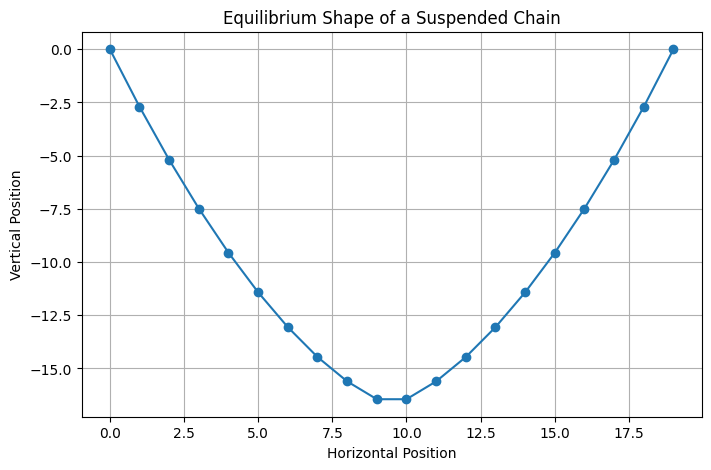

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(x, y, '-o')
plt.xlabel("Horizontal Position")
plt.ylabel("Vertical Position")
plt.title("Equilibrium Shape of a Suspended Chain")
plt.grid(True)
plt.show()

## Conclusion

In this experiment, the equilibrium shape of a suspended chain was determined using numerical optimization techniques. The chain was modeled as a series of discrete masses connected by springs, and the total energy of the system was defined as the sum of gravitational potential energy and elastic spring energy.

By minimizing this total energy using numerical methods, the equilibrium positions of the masses were obtained. The resulting configuration represents the stable shape that the chain assumes under the influence of gravity and spring tension.

The simulation demonstrates how physical systems naturally move toward states of minimum potential energy. The computed shape resembles the classical catenary curve, which is the theoretical shape of a hanging chain.

This numerical approach provides a simple yet powerful way to model mechanical systems and study equilibrium configurations using computational methods.